# Bimodal Gaussian location model

### Setup

We simulate bimodal data from a two-component Gaussian mixture, which we denote $P_0$ (see below). We define a misspecified unimodal normal-location model in PyMC and sample its predictively oriented posterior with `sample_pro`. Under misspecification, the PrO posterior predictive for $y$ should place mass near both mixture modes (Theorem 1, McLatchie et al., [arXiv:2510.01915](https://arxiv.org/abs/2510.01915)).

In [1]:
import numpy as np
import pymc as pm
import matplotlib.pyplot as plt
import seaborn as sns

from xarray import DataTree
from pymc_prop import sample_pro

FIGSIZE = (6.5, 4.0)
COLOR_DATA = "0.6"
COLOR_PRO = "#bca0ff"


## Simulate bimodal data

$$P_0 = 0.4\,\mathcal{N}(-1.5,\,0.7^2) + 0.6\,\mathcal{N}(2.25,\,0.7^2).$$

In [2]:
N = 800
sigma = 0.7
component_means = np.array([-1.5, 2.25])
component_weights = np.array([0.4, 0.6])
SEED = 2026

# draw component labels then observations -- reproducible rng
rng = np.random.default_rng(SEED)
components = rng.choice(len(component_means), size=N, p=component_weights)
y = rng.normal(loc=component_means[components], scale=sigma)

# plotting limits around component means
xlim = (component_means.min() - 3 * sigma, component_means.max() + 3 * sigma)


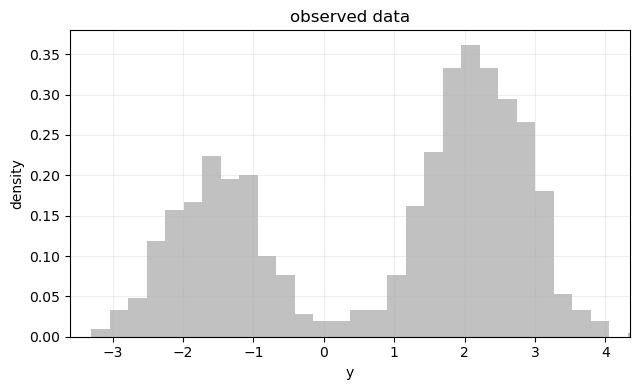

In [3]:
# histogram of the simulated data (verify bimodality)
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.hist(y, bins=30, density=True, color=COLOR_DATA, alpha=0.6)
ax.set(title="observed data", xlabel="y", ylabel="density", xlim=xlim)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## PyMC model (misspecified unimodal likelihood)

We place a prior $\mathcal{N}(0, 1)$ on $\mu$ and define
$y_i \mid \mu \sim \mathcal{N}(\mu, \sigma^2)$ with known $\sigma$ (same as in $P_0$).

In [4]:
# misspecified normal-location model: prior N(0,1) on mu; known sigma
with pm.Model() as model:
    mu = pm.Normal("mu", mu=0.0, sigma=1.0)
    pm.Normal("y", mu=mu, sigma=sigma, observed=y)


### Run the sampler

Sampling uses a particle-discretised Wasserstein gradient flow on $N = 800$ observations. We **retain every step** (`burn_in=0`, `thinning=1`) so we can plot full particle trajectories; the loop always runs `n_steps`, and `burn_in` only controls which steps are saved.

40 particles, 2500 steps, step size 8e-4, and learning rate $\lambda_n = 1$ (default). Below we plot particle trajectories, then a posterior predictive check in $y$-space.

In [5]:
# full trajectory for plotting (burn_in=0 saves every step)
dt = sample_pro(
    model=model,
    n_particles=40,
    n_steps=2500,
    step_size=8e-4,
    burn_in=0,
    thinning=1,
    random_seed=SEED,
)

# draw = retained steps; chain = particles
traj = dt.posterior["mu"].values
final_particles = traj[-1, :]
print("traj shape (n_retained, n_particles):", traj.shape)


traj shape (n_retained, n_particles): (2500, 40)


## ArviZ DataTree output

`sample_pro` returns `dt`, an ArviZ `xarray.DataTree`. Retained simulation steps map to **`draw`**; ensemble particles map to **`chain`**. The `draw` coordinate stores the simulation step index for each retained slice.

- `posterior` -> Free RVs (`mu` here)
- `observed_data` -> Constant observations from the PyMC model
- `log_likelihood` -> Per-observation log-probabilities
- `sample_stats` -> Particle spread and mean log-score along the flow

For downstream work (e.g. posterior predictive checks), take the final cloud with `dt.posterior.isel(draw=-1)`. Do not run default MCMC chain diagnostics (`az.rhat`, `az.ess`) over particles.

In [6]:
assert isinstance(dt, DataTree)
print("groups:", list(dt.children))
print("posterior dims:", dict(dt.posterior.sizes))
print("sample_dims:", dt.posterior.attrs["sample_dims"])
print("observed_data:", list(dt.observed_data.data_vars))
print("log_likelihood shape:", dt.log_likelihood["y"].shape)
print(
    "provenance:",
    {k: dt.attrs[k] for k in ("pro_burn_in", "pro_thinning", "pro_n_steps", "pro_learning_rate")},
)

# final empirical measure -- same particles as traj[-1]
final_dt = dt.posterior.isel(draw=-1)
np.testing.assert_allclose(final_dt["mu"].values.squeeze(), final_particles)

dt.posterior

groups: ['posterior', 'observed_data', 'log_likelihood', 'sample_stats']
posterior dims: {'draw': 2500, 'chain': 40}
sample_dims: ['draw', 'chain']
observed_data: ['y']
log_likelihood shape: (2500, 40, 800)
provenance: {'pro_burn_in': 0, 'pro_thinning': 1, 'pro_n_steps': 2500, 'pro_learning_rate': 1.0}


<xarray.DataTree 'posterior'>
Group: /posterior
    Dimensions:  (draw: 2500, chain: 40)
    Coordinates:
      * draw     (draw) int64 20kB 0 1 2 3 4 5 6 ... 2494 2495 2496 2497 2498 2499
      * chain    (chain) int64 320B 0 1 2 3 4 5 6 7 8 ... 31 32 33 34 35 36 37 38 39
    Data variables:
        mu       (draw, chain) float64 800kB 0.01728 1.24 -2.068 ... 2.067 2.46
    Attributes:
        created_at:                 2026-06-09T11:34:24.858181+00:00
        creation_library:           ArviZ
        creation_library_version:   1.1.0
        creation_library_language:  Python
        sample_dims:                ['draw', 'chain']
        inference_library:          pymc
        inference_library_version:  6.0.0

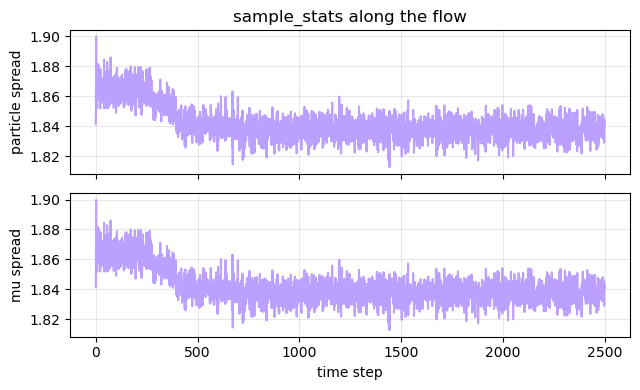

In [7]:
# sample_stats diagnostics (constant per draw; broadcast across chain for ArviZ schema)
steps = dt.posterior.coords["draw"].values
particle_spread = dt.sample_stats["particle_spread"].isel(chain=0).values
mu_spread = dt.sample_stats["mu_spread"].isel(chain=0).values

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=FIGSIZE, sharex=True)
ax0.plot(steps, particle_spread, color=COLOR_PRO)
ax0.set(ylabel="particle spread", title="sample_stats along the flow")
ax0.grid(alpha=0.3)
ax1.plot(steps, mu_spread, color=COLOR_PRO)
ax1.set(xlabel="time step", ylabel="mu spread")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Plots

### Particle trajectories

Each line is one particle $\mu_t^{(j)}$. Under misspecification, trajectories often split across both true component means.

### Posterior predictive (PrO vs data)

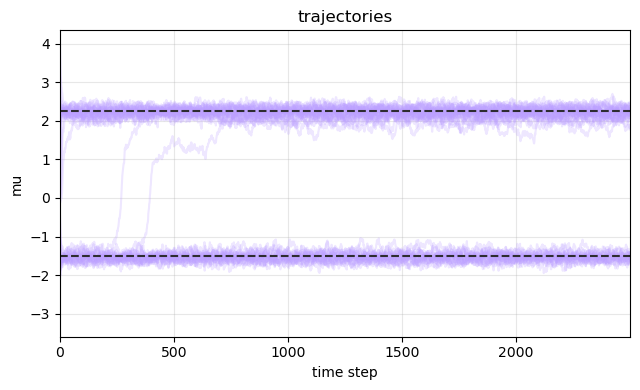

In [8]:
fig, ax = plt.subplots(figsize=FIGSIZE)
steps = dt.posterior.coords["draw"].values
for j in range(traj.shape[1]):
    # plot each particle's path through parameter space
    ax.plot(steps, traj[:, j], color=COLOR_PRO, alpha=0.25)
# show true component means for reference
for mu in component_means:
    ax.axhline(mu, **dict(color="0.15", linestyle="--", linewidth=1.5, alpha=0.95))
ax.set(
    title="trajectories",
    xlabel="time step",
    ylabel="mu",
    xlim=(0, steps[-1]),
    ylim=xlim,
)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


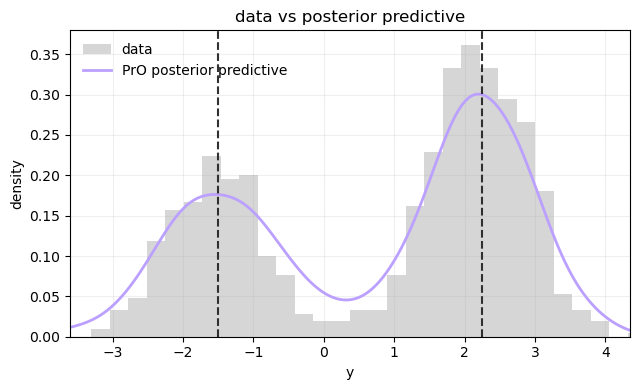

In [9]:
# PrO posterior predictive vs observed data (KDE of y_rep from final particles)
# build posterior predictive draws from final PrO particles
# repeat final mu particles to generate y_rep ~ N(mu_j, sigma^2)
n_rep = max(1, N // final_particles.shape[0])
rng_pp = np.random.default_rng(SEED + 1)
y_pp = rng_pp.normal(
    loc=np.repeat(final_particles, n_rep),
    scale=sigma,
)

fig, ax = plt.subplots(figsize=FIGSIZE)
grid = np.linspace(xlim[0], xlim[1], 400)

# overlay data histogram and PrO posterior predictive KDE
ax.hist(y, bins=30, density=True, alpha=0.4, color=COLOR_DATA, label="data")
sns.kdeplot(
    y_pp,
    ax=ax,
    color=COLOR_PRO,
    linewidth=2,
    bw_adjust=0.7,  # adjust smoothness as needed
    label="PrO posterior predictive",
)
for mu in component_means:
    ax.axvline(mu, **dict(color="0.15", linestyle="--", linewidth=1.5, alpha=0.95))

ax.set(title="data vs posterior predictive", xlabel="y", ylabel="density", xlim=xlim)
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
